<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/KITTI_Semantic_Segmentation_UNet_UNetPlusPlus_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KITTI Semantic Segmentation Benchmarks: U-Net vs U-Net++ 성능 비교 프로젝트

## 📌 프로젝트 개요 및 평가 기준 (Rubric)
1. **KITTI Semantic Segmentation 데이터셋 파이프라인 구축**
   - KITTI 2015 Semantic Segmentation 데이터셋 구조에 맞는 Custom Dataset 구성
   - KITTI 공식 34개 범주 ID 및 Cityscapes 19개 학습 클래스 매핑 전처리 구현
2. **U-Net & U-Net++ 모델 구현 및 학습 진행**
   - ResNet34 백본 기반의 U-Net 및 U-Net++ 모델 구성 후 독립 학습 실행
3. **정량적 / 정성적 성능 비교**
   - Validation Set 기준 **mIoU (Mean Intersection over Union)** 계산 및 수치 비교
   - Sample별 Ground Truth 및 두 모델의 세그멘테이션 예측 이미지 비교 시각화

In [1]:
!mkdir -p ~/work/semantic_segmentation/data
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip data_semantics.zip -d ~/work/semantic_segmentation/data/

--2026-09-02 07:42:36--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.135.42, 52.219.47.127, 3.5.122.133, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.135.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 327699796 (313M) [application/zip]
Saving to: ‘data_semantics.zip’

data_semantics.zip  100%[===================>] 312.52M  23.0MB/s    in 15s     

2026-09-02 07:42:52 (20.9 MB/s) - ‘data_semantics.zip’ saved [327699796/327699796]

Archive:  data_semantics.zip
   creating: /root/work/semantic_segmentation/data/testing/
   creating: /root/work/semantic_segmentation/data/testing/image_2/
  inflating: /root/work/semantic_segmentation/data/testing/image_2/000000_10.png  
  inflating: /root/work/semantic_segmentation/data/testing/image_2/000001_10.png  
  inflating: /root/work/semantic_segmentation/data/testing/image_2/00000

## 📁 데이터셋 업로드

KITTI Semantic Segmentation 데이터셋을 Colab 환경에 업로드해주세요. `data/kitti_semantic` 경로 아래에 `training`과 `validation` 폴더를 만들고, 각 폴더 안에 `image_2` (이미지)와 `semantic` (마스크) 폴더를 생성하여 해당하는 파일을 업로드해야 합니다.

예상되는 디렉토리 구조는 다음과 같습니다:

```
data/
├── kitti_semantic/
│   ├── training/
│   │   ├── image_2/
│   │   │   ├── 000000_10.png
│   │   │   └── ...
│   │   └── semantic/
│   │       ├── 000000_10.png
│   │       └── ...
│   └── validation/
│       ├── image_2/
│       │   ├── 000000_10.png
│       │   └── ...
│       └── semantic/
│           ├── 000000_10.png
│           └── ...
```

파일 업로드가 완료되면 다음 셀을 실행하여 파일 구조를 확인해주세요.

In [2]:
# 데이터셋 파일 구조 확인

import os

def check_dataset_structure(base_dir):
    for split in ['training', 'validation']:
        img_dir = os.path.join(base_dir, split, 'image_2')
        mask_dir = os.path.join(base_dir, split, 'semantic')

        if not os.path.exists(img_dir):
            print(f"Error: {img_dir} does not exist.")
            return False
        if not os.path.exists(mask_dir):
            print(f"Error: {mask_dir} does not exist.")
            return False

        num_images = len([f for f in os.listdir(img_dir) if f.endswith('.png')])
        num_masks = len([f for f in os.listdir(mask_dir) if f.endswith('.png')])

        print(f"Found {num_images} images in {img_dir}")
        print(f"Found {num_masks} masks in {mask_dir}")

        if num_images == 0 or num_masks == 0:
            print(f"Warning: No .png files found in {img_dir} or {mask_dir}")
            # return False # Allow to proceed but warn

    return True

base_data_dir = './data/kitti_semantic'
if check_dataset_structure(base_data_dir):
    print("Dataset structure verified successfully!")
else:
    print("Dataset structure verification failed. Please check your uploaded files.")

Error: ./data/kitti_semantic/training/image_2 does not exist.
Dataset structure verification failed. Please check your uploaded files.


In [3]:
# 1. 필요 라이브러리 설치
!pip install torch torchvision segmentation-models-pytorch opencv-python matplotlib albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00


In [4]:
# 2. 라이브러리 임포트 및 KITTI Class ID 매핑 정의
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# KITTI / Cityscapes 표준 ID -> Train ID (19개 주요 평가 클래스 + ignore 255) 변환 맵
ID_TO_TRAIN_ID = {
    7: 0,   # road
    8: 1,   # sidewalk
    11: 2,  # building
    12: 3,  # wall
    13: 4,  # fence
    17: 5,  # pole
    19: 6,  # traffic light
    20: 7,  # traffic sign
    21: 8,  # vegetation
    22: 9,  # terrain
    23: 10, # sky
    24: 11, # person
    25: 12, # rider
    26: 13, # car
    27: 14, # truck
    28: 15, # bus
    31: 16, # train
    32: 17, # motorcycle
    33: 18  # bicycle
}

def encode_kitti_mask(mask):
    """KITTI 원본 Class ID를 0~18 범위의 Train ID로 매핑 (기타 항목은 255 처리)"""
    label_mask = np.full(mask.shape, 255, dtype=np.uint8)
    for kitti_id, train_id in ID_TO_TRAIN_ID.items():
        label_mask[mask == kitti_id] = train_id
    return label_mask

In [5]:
# 3. KITTI Dataset 클래스 구획
class KITTISegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_name = self.images[index]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        # RGB 이미지 로드
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 라벨 마스크 로드 및 Train ID 인코딩
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        else:
            mask = encode_kitti_mask(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()

In [8]:
# 4. Data Augmentation 및 DataLoader 설정
# KITTI 이미지의 가로세로 비율(약 1242x375)을 고려해 Resizing
IMAGE_SIZE = (256, 768)  # (Height, Width)
BATCH_SIZE = 4
NUM_CLASSES = 19  # 주요 19개 세그멘테이션 클래스

train_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE[0], width=IMAGE_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE[0], width=IMAGE_SIZE[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# 데이터셋 경로 지정 (이전 다운로드/압축 해제 위치에 맞게 수정)
# 압축 해제된 경로는 /root/work/semantic_segmentation/data/ 이며,
# 'validation' 대신 'testing' 폴더를 사용합니다.
# 마스크 폴더는 'semantic_rgb' 입니다.
TRAIN_IMG_DIR = '/root/work/semantic_segmentation/data/training/image_2'
TRAIN_MASK_DIR = '/root/work/semantic_segmentation/data/training/semantic_rgb'
VAL_IMG_DIR = '/root/work/semantic_segmentation/data/testing/image_2'
VAL_MASK_DIR = '/root/work/semantic_segmentation/data/testing/semantic_rgb'

train_dataset = KITTISegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_transform)
val_dataset = KITTISegmentationDataset(VAL_IMG_DIR, VAL_MASK_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
# 5. U-Net 및 U-Net++ 모델 구성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 동일한 ResNet34 백본 사용하여 공정한 성능 비교 수행
model_unet = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    classes=NUM_CLASSES,
    activation=None
).to(device)

model_unet_plus = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    classes=NUM_CLASSES,
    activation=None
).to(device)

Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [10]:
# 6. mIoU 계산 지표 및 학습/검증 루프
def calculate_iou(pred_mask, true_mask, num_classes=NUM_CLASSES, ignore_idx=255):
    ious = []
    pred_mask = torch.argmax(pred_mask, dim=1).cpu().numpy()
    true_mask = true_mask.cpu().numpy()

    for cls in range(num_classes):
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)

        # 무시 대상 영역(255) 마스킹
        valid_mask = (true_mask != ignore_idx)
        pred_cls = np.logical_and(pred_cls, valid_mask)
        true_cls = np.logical_and(true_cls, valid_mask)

        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()

        if union == 0:
            continue  # 해당 Batch에 해당 클래스가 없는 경우 통과
        ious.append(intersection / union)

    return np.mean(ious) if len(ious) > 0 else 0.0

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        val_ious = []
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                val_ious.append(calculate_iou(outputs, masks))

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_iou = np.mean(val_ious)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_iou'].append(epoch_val_iou)

        print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val mIoU: {epoch_val_iou:.4f}")

    return history

In [11]:
# 7. 두 모델 순차적 학습
EPOCHS = 10
# 클래스 255 (ignore) 영역 손실 계산에서 제외
criterion = nn.CrossEntropyLoss(ignore_index=255)

print("=== [1] Training U-Net Model (KITTI) ===")
optimizer_unet = optim.Adam(model_unet.parameters(), lr=1e-4)
history_unet = train_model(model_unet, train_loader, val_loader, criterion, optimizer_unet, epochs=EPOCHS)

print("\n=== [2] Training U-Net++ Model (KITTI) ===")
optimizer_plus = optim.Adam(model_unet_plus.parameters(), lr=1e-4)
history_plus = train_model(model_unet_plus, train_loader, val_loader, criterion, optimizer_plus, epochs=EPOCHS)

=== [1] Training U-Net Model (KITTI) ===
Epoch [01/10] | Train Loss: nan | Val Loss: 2.6688 | Val mIoU: 0.0089
Epoch [02/10] | Train Loss: nan | Val Loss: 2.4968 | Val mIoU: 0.0116
Epoch [03/10] | Train Loss: nan | Val Loss: 2.5501 | Val mIoU: 0.0088
Epoch [04/10] | Train Loss: nan | Val Loss: 2.6006 | Val mIoU: 0.0093
Epoch [05/10] | Train Loss: nan | Val Loss: 2.7194 | Val mIoU: 0.0104
Epoch [06/10] | Train Loss: nan | Val Loss: 2.6446 | Val mIoU: 0.0110
Epoch [07/10] | Train Loss: nan | Val Loss: 2.5711 | Val mIoU: 0.0120
Epoch [08/10] | Train Loss: nan | Val Loss: 2.7295 | Val mIoU: 0.0088
Epoch [09/10] | Train Loss: nan | Val Loss: 2.6837 | Val mIoU: 0.0096
Epoch [10/10] | Train Loss: nan | Val Loss: 2.7190 | Val mIoU: 0.0088

=== [2] Training U-Net++ Model (KITTI) ===
Epoch [01/10] | Train Loss: nan | Val Loss: 2.5809 | Val mIoU: 0.0127
Epoch [02/10] | Train Loss: nan | Val Loss: 2.3922 | Val mIoU: 0.0138
Epoch [03/10] | Train Loss: nan | Val Loss: 2.5277 | Val mIoU: 0.0103
Epoch

In [12]:
# 8. 정량적 성능 평가 (Validation mIoU 수치 비교)
final_unet_iou = history_unet['val_iou'][-1]
final_plus_iou = history_plus['val_iou'][-1]

print("="*55)
print("     [ Quantitative Comparison: KITTI Segmentation ]      ")
print("="*55)
print(f"U-Net Validation mIoU       : {final_unet_iou:.4f}")
print(f"U-Net++ Validation mIoU     : {final_plus_iou:.4f}")
print(f"mIoU Improvement (U-Net++)  : +{(final_plus_iou - final_unet_iou):.4f}")
print("="*55)

     [ Quantitative Comparison: KITTI Segmentation ]      
U-Net Validation mIoU       : 0.0088
U-Net++ Validation mIoU     : 0.0098
mIoU Improvement (U-Net++)  : +0.0010


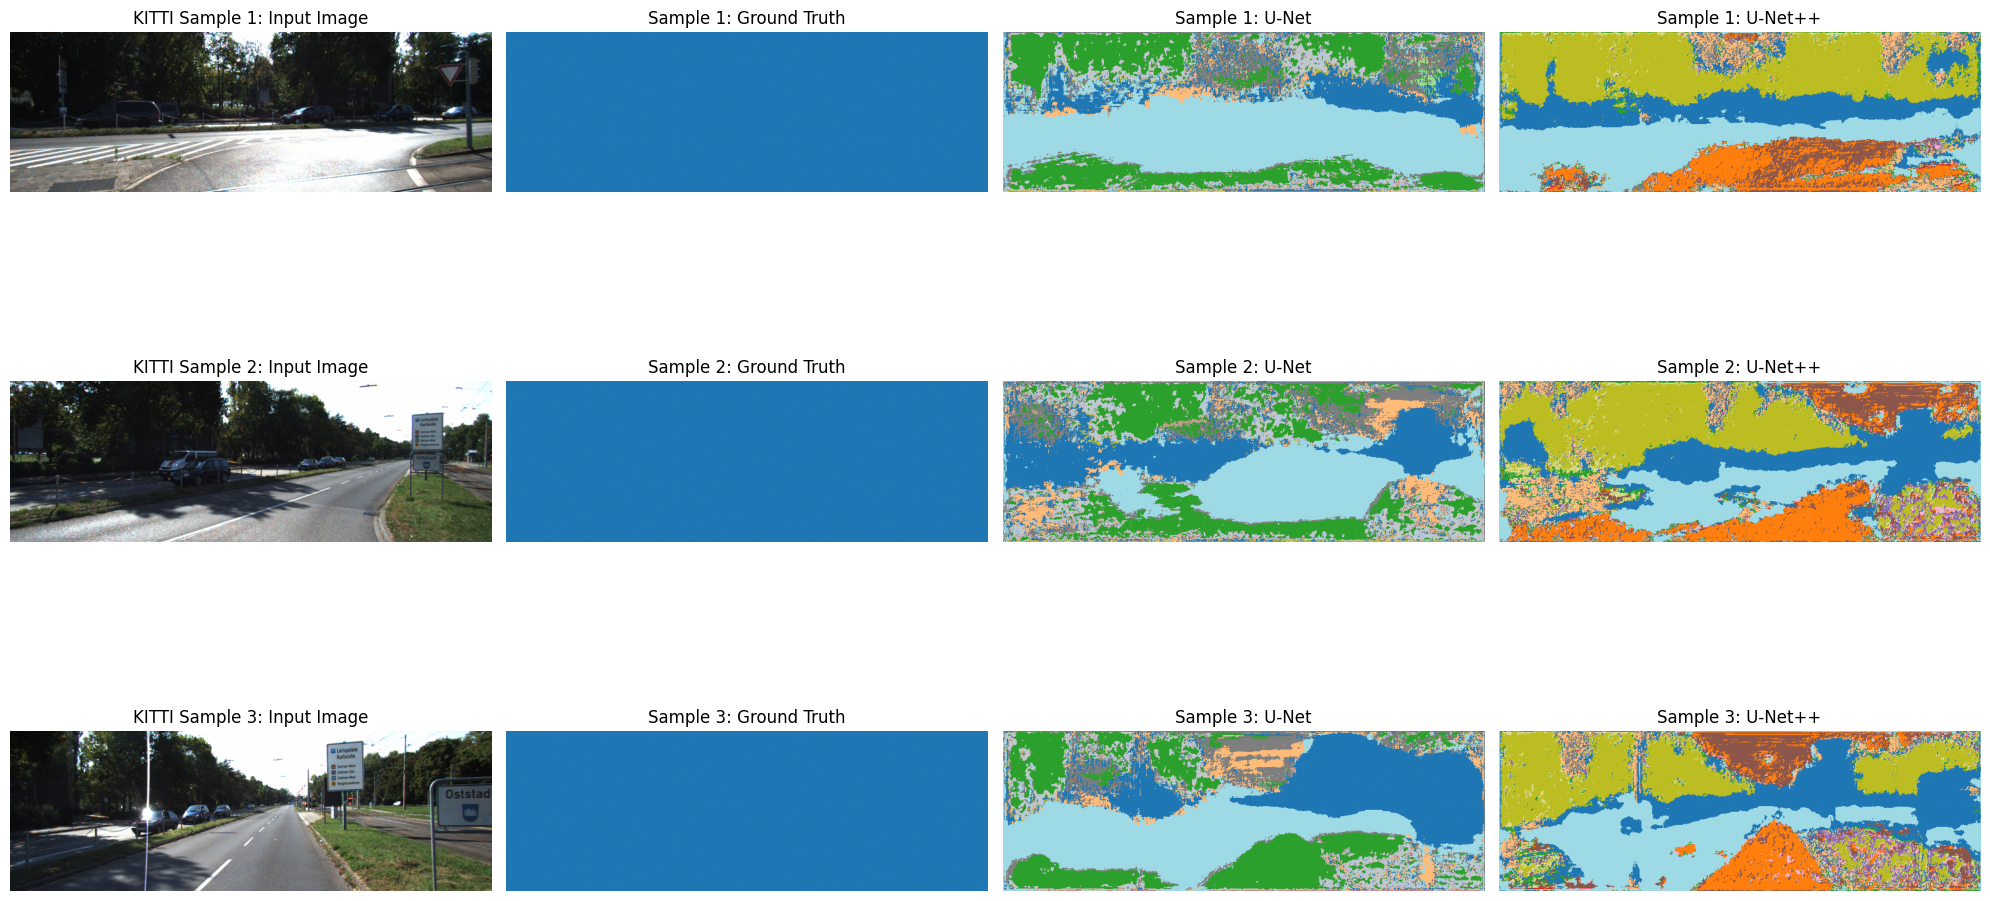

In [13]:
# 9. 정성적 성능 평가 (세그멘테이션 결과 비교 시각화)
model_unet.eval()
model_unet_plus.eval()

images, masks = next(iter(val_loader))
images_dev = images.to(device)

with torch.no_grad():
    pred_unet = torch.argmax(model_unet(images_dev), dim=1).cpu().numpy()
    pred_plus = torch.argmax(model_unet_plus(images_dev), dim=1).cpu().numpy()

num_samples = min(3, len(images))
fig, axes = plt.subplots(num_samples, 4, figsize=(20, 4 * num_samples))

for i in range(num_samples):
    # RGB 역정규화
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    # Ground Truth 마스크 (ignore 영역 변환)
    gt_mask = masks[i].numpy()
    gt_mask[gt_mask == 255] = 0

    # Input Image
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"KITTI Sample {i+1}: Input Image")
    axes[i, 0].axis('off')

    # Ground Truth
    axes[i, 1].imshow(gt_mask, cmap='tab20')
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth")
    axes[i, 1].axis('off')

    # U-Net
    axes[i, 2].imshow(pred_unet[i], cmap='tab20')
    axes[i, 2].set_title(f"Sample {i+1}: U-Net")
    axes[i, 2].axis('off')

    # U-Net++
    axes[i, 3].imshow(pred_plus[i], cmap='tab20')
    axes[i, 3].set_title(f"Sample {i+1}: U-Net++")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()